03_Perspectives_and_Issues.ipynb

1. Introduction
2. Why Deep Learning Is Difficult
3. Representation Learning Perspective
4. Optimization Perspective
5. Generalization Perspective
6. Data Perspective
7. Computational Perspective
8. Vanishing and Exploding Gradients
9. Internal Covariate Shift
10. Overfitting and Regularization
11. Initialization Issues
12. Dead Neurons
13. Loss Function Issues
14. Class Imbalance
15. Data Quality and Distribution Shift
16. Interpretability and Explainability
17. Computational and Memory Issues
18. Practical PyTorch Demonstrations
19. Summary
20. Key Exam Points
21. Practice Questions

# 03 — Perspectives and Issues in Deep Learning

Deep Learning is a subfield of machine learning that uses neural networks with multiple layers to learn hierarchical representations from data.

While deep neural networks are powerful, training them successfully introduces several challenges related to:

- Representation learning
- Optimization
- Generalization
- Data
- Computation
- Numerical stability
- Model architecture
- Interpretability

This notebook studies Deep Learning from different perspectives and examines the major issues that arise while designing and training deep neural networks.

## Learning Objectives

By the end of this notebook, we should be able to:

1. Understand different perspectives for studying deep learning.
2. Explain why deep neural networks are difficult to train.
3. Understand optimization-related problems.
4. Explain vanishing and exploding gradients.
5. Understand initialization and activation-function issues.
6. Analyze overfitting and generalization problems.
7. Understand data-related challenges such as class imbalance and distribution shift.
8. Understand computational and memory limitations.
9. Discuss interpretability and explainability.
10. Experiment with important issues using PyTorch.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 1. Major Perspectives in Deep Learning

Deep Learning can be understood from several complementary perspectives.

### 1. Representation Perspective

A neural network transforms raw input into increasingly meaningful representations.

For a network with multiple layers:

$$
h^{(1)} = f_1(x)
$$

$$
h^{(2)} = f_2(h^{(1)})
$$

$$
\cdots
$$

$$
h^{(L)} = f_L(h^{(L-1)})
$$

The final representation can then be used to produce a prediction.

The important idea is that the network learns the representation automatically rather than requiring all useful features to be manually engineered.

---

### 2. Optimization Perspective

Training a neural network involves finding parameters that minimize a loss function.

Let the parameters of the network be represented by:

$$
\theta
$$

The training objective is:

$$
\theta^* = \arg\min_{\theta} L(\theta)
$$

Optimization algorithms such as Gradient Descent and Adam attempt to find parameters that produce a low training loss.

---

### 3. Generalization Perspective

A model should not merely memorize the training data.

We want it to perform well on unseen examples.

The difference between training performance and test performance is therefore important.

A model can have:

- High training accuracy and high test accuracy → good generalization
- High training accuracy and low test accuracy → overfitting
- Low training accuracy and low test accuracy → underfitting

---

### 4. Data Perspective

Deep learning systems depend heavily on the quality, quantity, and distribution of data.

Important issues include:

- Insufficient training data
- Noisy labels
- Missing data
- Class imbalance
- Data leakage
- Distribution shift
- Dataset bias

A sophisticated neural network cannot completely compensate for fundamentally poor data.

---

### 5. Computational Perspective

Deep neural networks may contain millions or even billions of parameters.

Training can therefore require substantial:

- CPU/GPU computation
- Memory
- Storage
- Training time
- Energy

Modern deep learning relies heavily on GPUs and specialized hardware to make training practical.

## 2. Representation Learning Perspective

One of the central ideas behind Deep Learning is **hierarchical representation learning**.

Instead of directly learning a mapping from raw input to output, a deep neural network learns a sequence of intermediate representations.

For example, in image recognition:

$$
\text{Pixels}
\rightarrow
\text{Edges}
\rightarrow
\text{Textures}
\rightarrow
\text{Parts}
\rightarrow
\text{Objects}
$$

Different layers can therefore learn different levels of abstraction.

### Example

For an image-classification network:

$$
x \rightarrow h^{(1)} \rightarrow h^{(2)} \rightarrow h^{(3)} \rightarrow \hat{y}
$$

where:

- $x$ = input image
- $h^{(1)}$ = low-level representation
- $h^{(2)}$ = intermediate representation
- $h^{(3)}$ = high-level representation
- $\hat{y}$ = prediction

This hierarchical structure is one of the major reasons deep neural networks are powerful.

## 3. Optimization Perspective

Training a neural network can be viewed as an optimization problem.

Suppose the network has parameters:

$$
\theta = \{W_1, b_1, W_2, b_2, \ldots, W_L, b_L\}
$$

The loss function measures how different the predictions are from the target values.

The optimization objective is:

$$
\min_{\theta} L(\theta)
$$

Gradient Descent updates the parameters according to:

$$
\theta_{t+1}
=
\theta_t
-
\eta \nabla_{\theta}L(\theta_t)
$$

where:

- $\eta$ = learning rate
- $\nabla_{\theta}L$ = gradient of the loss with respect to parameters

### Important optimization issues

Deep networks may suffer from:

- Poor initialization
- Vanishing gradients
- Exploding gradients
- Saddle points
- Poor learning rates
- Unstable optimization
- Highly non-convex loss landscapes

## simple optimization example

In [2]:
x = torch.tensor([1.0, 2.0, 3.0, 4.0])
y = torch.tensor([2.0, 4.0, 6.0, 8.0])

model = nn.Linear(1, 1)

optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

loss_history = []

for epoch in range(500):
    predictions = model(x.reshape(-1, 1))

    loss = criterion(predictions, y.reshape(-1, 1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

print("Final loss:", loss_history[-1])

Final loss: 0.00910668633878231


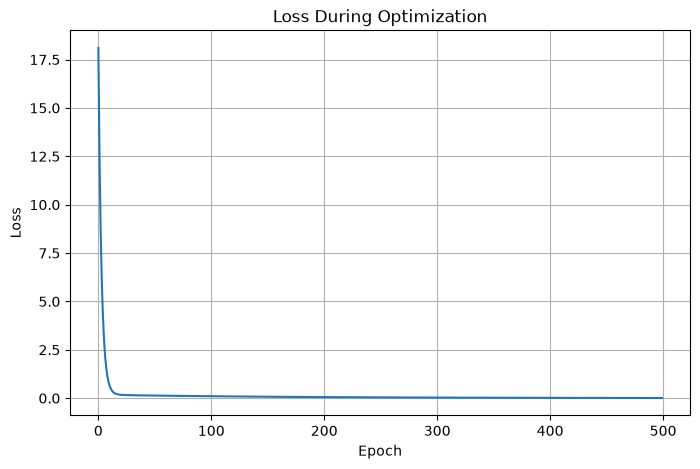

In [3]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss During Optimization")
plt.grid(True)

plt.show()

## 4. Generalization Perspective

A deep learning model is useful only if it can perform well on data that it has not seen during training.

The expected performance on unseen data is related to **generalization**.

A useful conceptual distinction is:

$$
\text{Training Error}
\neq
\text{Generalization Error}
$$

### Overfitting

Overfitting occurs when a model learns the training data too closely and performs poorly on unseen data.

Typical behavior:

$$
\text{Training Loss} \downarrow
$$

while:

$$
\text{Validation Loss} \uparrow
$$

### Underfitting

Underfitting occurs when the model is not sufficiently capable of learning the underlying patterns.

Typical behavior:

$$
\text{Training Loss is high}
$$

and:

$$
\text{Validation Loss is also high}
$$

## 5. Vanishing Gradient Problem

The vanishing gradient problem occurs when gradients become extremely small as they are propagated backward through many layers.

During backpropagation, gradients are obtained using the chain rule.

Consider:

$$
\frac{\partial L}{\partial W_1}
=
\frac{\partial L}{\partial h_L}
\frac{\partial h_L}{\partial h_{L-1}}
\cdots
\frac{\partial h_2}{\partial h_1}
\frac{\partial h_1}{\partial W_1}
$$

This involves multiplying many derivatives.

If these derivatives are generally smaller than 1, their product can become extremely small.

For example:

$$
0.5^{10} \approx 0.00098
$$

and:

$$
0.5^{50} \approx 8.88 \times 10^{-16}
$$

Therefore, early layers may receive almost no useful gradient.

### Consequences

- Early layers learn extremely slowly.
- Training becomes difficult.
- Network convergence can become very slow.
- Deep networks may fail to learn useful representations.

### Common solutions

Several techniques help reduce this problem:

- ReLU and related activation functions
- Proper parameter initialization
- Batch Normalization
- Residual connections
- Carefully designed architectures

## 6. Exploding Gradient Problem

The opposite problem is the **exploding gradient problem**.

If gradients repeatedly multiply by values greater than 1, their magnitude can grow rapidly.

For example:

$$
2^{10} = 1024
$$

and:

$$
2^{50} \approx 1.13 \times 10^{15}
$$

Very large gradients can result in:

- Extremely large parameter updates
- Numerical instability
- Loss becoming NaN
- Training failure

### Common solution

A widely used technique is **gradient clipping**.

For example:

$$
g
\leftarrow
g \frac{\tau}{\|g\|}
$$

when:

$$
\|g\| > \tau
$$

where $\tau$ is the maximum allowed gradient norm.

## 7. Parameter Initialization

The initial values of neural-network parameters can strongly affect training.

Poor initialization can cause:

- Vanishing activations
- Exploding activations
- Vanishing gradients
- Exploding gradients
- Slow convergence

### Xavier Initialization

Xavier initialization is commonly associated with sigmoid and tanh activations.

A simplified variance relationship is:

$$
\operatorname{Var}(W)
\approx
\frac{2}{n_{in}+n_{out}}
$$

### He Initialization

He initialization is particularly suitable for ReLU-based networks.

A common form is:

$$
\operatorname{Var}(W)
\approx
\frac{2}{n_{in}}
$$

Good initialization attempts to keep signal magnitudes reasonably stable as they propagate through the network.

## 8. Dead ReLU Neurons

ReLU is defined as:

$$
f(x)=\max(0,x)
$$

For negative inputs:

$$
f(x)=0
$$

and the derivative is:

$$
f'(x)=0
$$

for:

$$
x<0
$$

If a neuron consistently receives negative inputs, it can stop producing useful gradients.

Such a neuron is sometimes called a **dead neuron**.

### Possible solutions

- Better initialization
- Appropriate learning rate
- Leaky ReLU
- ELU
- Other activation functions

## 9. Data-Related Issues

Deep learning performance is strongly influenced by the training data.

### 9.1 Insufficient Data

Large neural networks often require substantial amounts of training data.

When data is limited, the model may overfit.

---

### 9.2 Noisy Labels

Incorrect labels can cause the model to learn incorrect relationships.

---

### 9.3 Class Imbalance

Suppose a classification dataset contains:

$$
95\% \text{ Class A}
$$

and:

$$
5\% \text{ Class B}
$$

A model predicting Class A for every sample would achieve:

$$
95\%
$$

accuracy while completely failing to identify Class B.

Therefore, accuracy alone may be misleading.

---

### 9.4 Data Leakage

Data leakage occurs when information unavailable during real-world prediction accidentally enters the training process.

This can produce unrealistically high evaluation performance.

---

### 9.5 Distribution Shift

Training and deployment data may come from different distributions.

Conceptually:

$$
P_{train}(X,Y)
\neq
P_{deployment}(X,Y)
$$

This can significantly reduce model performance.

## 10. Interpretability and Explainability

Deep neural networks can contain a very large number of parameters and complicated nonlinear transformations.

Consequently, understanding why a model produced a particular prediction can be difficult.

This is often described using the term:

**Black-box model**

Interpretability becomes especially important in applications such as:

- Healthcare
- Finance
- Autonomous systems
- Security
- Scientific research

Important approaches include:

- Feature attribution
- Saliency methods
- Attention analysis
- Activation visualization
- Grad-CAM
- SHAP
- Local explanations
- Counterfactual explanations

Explainability does not necessarily mean that the model becomes completely transparent, but it can provide useful evidence about the model's behavior.

## 11. Computational and Memory Issues

Deep neural networks can be computationally expensive.

The major requirements include:

### Computational resources

- CPU
- GPU
- TPU
- Specialized accelerators

### Memory requirements

During training, memory is required for:

- Model parameters
- Gradients
- Activations
- Optimizer states
- Input batches

For large models, GPU memory can become a major limitation.

### Common solutions

- Mini-batch training
- Mixed precision
- Gradient accumulation
- Model quantization
- Pruning
- Knowledge distillation
- Efficient architectures
- Distributed training

# 12. Summary

Deep Learning can be studied from several important perspectives.

### Representation Perspective

Deep networks learn hierarchical representations from raw data.

### Optimization Perspective

Training involves minimizing a loss function through optimization algorithms.

### Generalization Perspective

The model must perform well on unseen data rather than simply memorizing the training set.

### Data Perspective

Data quality, quantity, class balance, leakage, and distribution shift strongly affect performance.

### Computational Perspective

Deep models require substantial computational power and memory.

### Major Training Issues

Important issues include:

- Vanishing gradients
- Exploding gradients
- Poor initialization
- Dead neurons
- Overfitting
- Underfitting
- Data imbalance
- Distribution shift
- Computational limitations
- Interpretability challenges

# 13. Key Exam Points

## Very Important Questions

1. Explain the different perspectives of Deep Learning.
2. What is the vanishing gradient problem?
3. What is the exploding gradient problem?
4. Explain the role of parameter initialization.
5. Compare Xavier and He initialization.
6. What are dead ReLU neurons?
7. Explain overfitting and underfitting in Deep Learning.
8. What is class imbalance?
9. What is data leakage?
10. Explain distribution shift.
11. Why is interpretability difficult in Deep Learning?
12. Discuss computational challenges in training deep neural networks.

## Important Formulas

Gradient Descent:

$$
\theta_{t+1}
=
\theta_t
-
\eta\nabla_\theta L(\theta_t)
$$

ReLU:

$$
f(x)=\max(0,x)
$$

Xavier variance:

$$
\operatorname{Var}(W)
\approx
\frac{2}{n_{in}+n_{out}}
$$

He variance:

$$
\operatorname{Var}(W)
\approx
\frac{2}{n_{in}}
$$

# 14. Practical Experiment: Vanishing Gradients

We can demonstrate the vanishing-gradient problem using a deep neural network with sigmoid activations.

The sigmoid function is:

$$
\sigma(x)=\frac{1}{1+e^{-x}}
$$

Its derivative is:

$$
\sigma'(x)=\sigma(x)(1-\sigma(x))
$$

The maximum value of the derivative is:

$$
\max \sigma'(x)=\frac{1}{4}
$$

Therefore, when many sigmoid layers are stacked together, gradients can become very small during backpropagation.

We will compare gradient magnitudes in a deep network using:

- Sigmoid activation
- ReLU activation

In [4]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)


class DeepSigmoidNetwork(nn.Module):
    def __init__(self, depth=10):
        super().__init__()

        layers = []

        for _ in range(depth):
            layers.append(nn.Linear(32, 32))
            layers.append(nn.Sigmoid())

        layers.append(nn.Linear(32, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


class DeepReLUNetwork(nn.Module):
    def __init__(self, depth=10):
        super().__init__()

        layers = []

        for _ in range(depth):
            layers.append(nn.Linear(32, 32))
            layers.append(nn.ReLU())

        layers.append(nn.Linear(32, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [5]:
x = torch.randn(64, 32)
y = torch.randn(64, 1)

sigmoid_model = DeepSigmoidNetwork(depth=10)
relu_model = DeepReLUNetwork(depth=10)

criterion = nn.MSELoss()

sigmoid_output = sigmoid_model(x)
sigmoid_loss = criterion(sigmoid_output, y)

sigmoid_loss.backward()

relu_output = relu_model(x)
relu_loss = criterion(relu_output, y)

relu_loss.backward()

In [6]:
sigmoid_gradients = []
relu_gradients = []

for name, parameter in sigmoid_model.named_parameters():
    if parameter.grad is not None and "weight" in name:
        sigmoid_gradients.append(parameter.grad.abs().mean().item())

for name, parameter in relu_model.named_parameters():
    if parameter.grad is not None and "weight" in name:
        relu_gradients.append(parameter.grad.abs().mean().item())

print("Sigmoid gradient magnitudes:")
print(sigmoid_gradients)

print("\nReLU gradient magnitudes:")
print(relu_gradients)

Sigmoid gradient magnitudes:
[6.213945330513226e-11, 5.489474430575569e-10, 3.067210485596661e-09, 3.0600524780766136e-08, 2.0413253309925494e-07, 1.230900352311437e-06, 9.174967999570072e-06, 7.375722634606063e-05, 0.0006231977022252977, 0.005758646409958601, 0.2307538390159607]

ReLU gradient magnitudes:
[2.4196660888264887e-06, 2.79647338174982e-06, 3.0352978228620486e-06, 3.0493747544824146e-06, 4.192242158751469e-06, 1.0746535735961515e-05, 3.694355473271571e-05, 0.0001679717970546335, 0.0003438462154008448, 0.0008419440127909184, 0.02456812933087349]


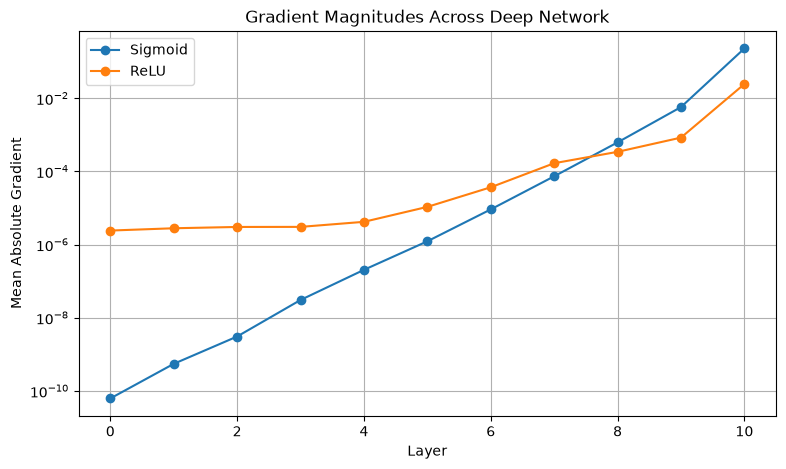

In [7]:
plt.figure(figsize=(9, 5))

plt.plot(sigmoid_gradients, marker="o", label="Sigmoid")
plt.plot(relu_gradients, marker="o", label="ReLU")

plt.yscale("log")

plt.xlabel("Layer")
plt.ylabel("Mean Absolute Gradient")
plt.title("Gradient Magnitudes Across Deep Network")
plt.legend()
plt.grid(True)

plt.show()

### Observation

The sigmoid network tends to produce substantially smaller gradients in earlier layers.

This demonstrates the basic mechanism behind the vanishing-gradient problem.

ReLU generally maintains stronger gradients for positive activations, making optimization easier in many deep architectures.

However, ReLU itself has other issues, including the possibility of dead neurons.

# 15. Practical Experiment: Exploding Gradients

Exploding gradients occur when gradients become extremely large during backpropagation.

A simple way to observe this behavior is to construct a network with unusually large parameter values.

Very large gradients can result in:

$$
\|\nabla_\theta L\| \rightarrow \text{very large}
$$

This can cause unstable parameter updates.

We will then demonstrate gradient clipping.

In [8]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Linear(10, 50),
    nn.ReLU(),
    nn.Linear(50, 50),
    nn.ReLU(),
    nn.Linear(50, 1)
)

for parameter in model.parameters():
    if parameter.dim() > 1:
        nn.init.constant_(parameter, 5.0)

x = torch.randn(32, 10)
y = torch.randn(32, 1)

criterion = nn.MSELoss()

output = model(x)
loss = criterion(output, y)

loss.backward()

In [9]:
total_gradient_norm = torch.sqrt(
    sum(
        torch.sum(parameter.grad ** 2)
        for parameter in model.parameters()
        if parameter.grad is not None
    )
)

print("Gradient norm before clipping:", total_gradient_norm.item())

Gradient norm before clipping: 34806779904.0


## Gradient Clipping

Gradient clipping limits the magnitude of gradients before updating parameters.

For example:

$$
g_{clipped}
=
g
\frac{\tau}{\|g\|}
$$

when:

$$
\|g\|>\tau
$$

where $\tau$ is the clipping threshold.

In [10]:
max_norm = 1.0

torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=max_norm
)

clipped_gradient_norm = torch.sqrt(
    sum(
        torch.sum(parameter.grad ** 2)
        for parameter in model.parameters()
        if parameter.grad is not None
    )
)

print("Gradient norm after clipping:", clipped_gradient_norm.item())

Gradient norm after clipping: 0.9999999403953552


Gradient clipping does not solve the underlying cause of exploding gradients, but it can prevent excessively large updates and improve training stability.

Gradient clipping is particularly important in some sequence models and other situations where gradient explosions can occur.

# 16. Practical Experiment: Weight Initialization

We will compare different initialization strategies.

The three cases are:

1. Very small initialization
2. Xavier initialization
3. He initialization

The goal is to understand how initialization influences activation magnitudes.

In [11]:
def create_network(initialization):
    model = nn.Sequential(
        nn.Linear(100, 100),
        nn.ReLU(),
        nn.Linear(100, 100),
        nn.ReLU(),
        nn.Linear(100, 100),
        nn.ReLU(),
        nn.Linear(100, 10)
    )

    for layer in model:
        if isinstance(layer, nn.Linear):
            if initialization == "small":
                nn.init.normal_(layer.weight, mean=0.0, std=0.01)

            elif initialization == "xavier":
                nn.init.xavier_normal_(layer.weight)

            elif initialization == "he":
                nn.init.kaiming_normal_(
                    layer.weight,
                    nonlinearity="relu"
                )

            nn.init.zeros_(layer.bias)

    return model

In [12]:
x = torch.randn(128, 100)

models = {
    "Small": create_network("small"),
    "Xavier": create_network("xavier"),
    "He": create_network("he")
}

activation_statistics = {}

for name, model in models.items():
    activations = x

    layer_means = []
    layer_stds = []

    for layer in model:
        activations = layer(activations)

        if isinstance(layer, nn.ReLU):
            layer_means.append(activations.mean().item())
            layer_stds.append(activations.std().item())

    activation_statistics[name] = {
        "means": layer_means,
        "stds": layer_stds
    }

activation_statistics

{'Small': {'means': [0.039831385016441345,
   0.002908765571191907,
   0.00021281607041601092],
  'stds': [0.05854368582367897, 0.004241836257278919, 0.00030671723652631044]},
 'Xavier': {'means': [0.40829694271087646,
   0.25488486886024475,
   0.19778253138065338],
  'stds': [0.5963985919952393, 0.39186009764671326, 0.27935442328453064]},
 'He': {'means': [0.5595331192016602, 0.6786279082298279, 0.5722764134407043],
  'stds': [0.8355923891067505, 0.9112178087234497, 0.8803450465202332]}}

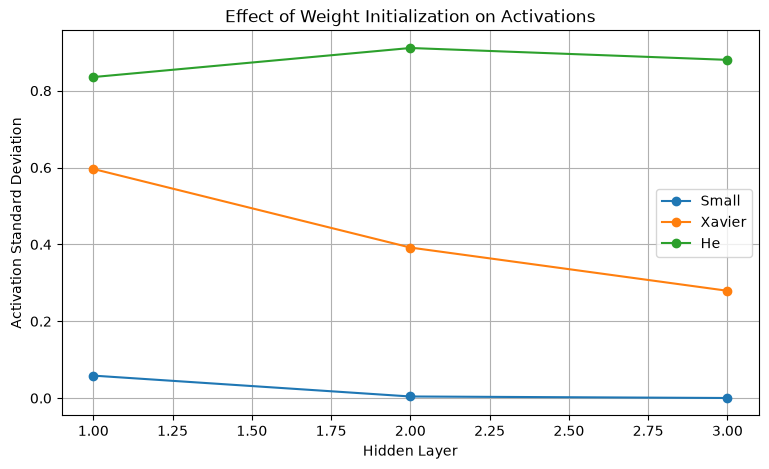

In [13]:
plt.figure(figsize=(9, 5))

for name, values in activation_statistics.items():
    plt.plot(
        range(1, len(values["stds"]) + 1),
        values["stds"],
        marker="o",
        label=name
    )

plt.xlabel("Hidden Layer")
plt.ylabel("Activation Standard Deviation")
plt.title("Effect of Weight Initialization on Activations")
plt.legend()
plt.grid(True)

plt.show()

### Observation

Initialization affects how signals propagate through a deep network.

He initialization is designed specifically to work well with ReLU-like activations by maintaining a suitable variance of activations.

Xavier initialization is commonly associated with symmetric activations such as tanh and is also useful in many other settings.

The important principle is:

> Good initialization helps maintain stable signal and gradient propagation through the network.

# 16. Practical Experiment: Weight Initialization

We will compare different initialization strategies.

The three cases are:

1. Very small initialization
2. Xavier initialization
3. He initialization

The goal is to understand how initialization influences activation magnitudes.

In [14]:
def create_network(initialization):
    model = nn.Sequential(
        nn.Linear(100, 100),
        nn.ReLU(),
        nn.Linear(100, 100),
        nn.ReLU(),
        nn.Linear(100, 100),
        nn.ReLU(),
        nn.Linear(100, 10)
    )

    for layer in model:
        if isinstance(layer, nn.Linear):
            if initialization == "small":
                nn.init.normal_(layer.weight, mean=0.0, std=0.01)

            elif initialization == "xavier":
                nn.init.xavier_normal_(layer.weight)

            elif initialization == "he":
                nn.init.kaiming_normal_(
                    layer.weight,
                    nonlinearity="relu"
                )

            nn.init.zeros_(layer.bias)

    return model

In [15]:
x = torch.randn(128, 100)

models = {
    "Small": create_network("small"),
    "Xavier": create_network("xavier"),
    "He": create_network("he")
}

activation_statistics = {}

for name, model in models.items():
    activations = x

    layer_means = []
    layer_stds = []

    for layer in model:
        activations = layer(activations)

        if isinstance(layer, nn.ReLU):
            layer_means.append(activations.mean().item())
            layer_stds.append(activations.std().item())

    activation_statistics[name] = {
        "means": layer_means,
        "stds": layer_stds
    }

activation_statistics

{'Small': {'means': [0.040566496551036835,
   0.002844932721927762,
   0.00019514722225721925],
  'stds': [0.05926043912768364, 0.004132638219743967, 0.0002810751902870834]},
 'Xavier': {'means': [0.3894774615764618,
   0.25321313738822937,
   0.20008133351802826],
  'stds': [0.5782997608184814, 0.38877543807029724, 0.28945761919021606]},
 'He': {'means': [0.5587729811668396, 0.5917945504188538, 0.5584336519241333],
  'stds': [0.8245671391487122, 0.8446707129478455, 0.8609877228736877]}}

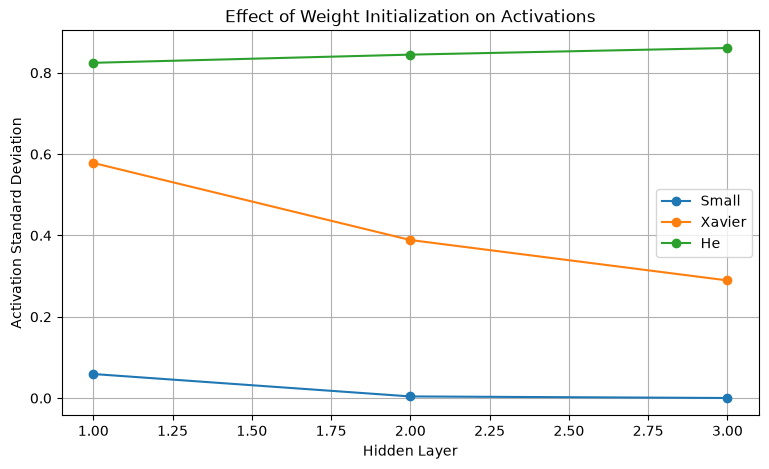

In [16]:
plt.figure(figsize=(9, 5))

for name, values in activation_statistics.items():
    plt.plot(
        range(1, len(values["stds"]) + 1),
        values["stds"],
        marker="o",
        label=name
    )

plt.xlabel("Hidden Layer")
plt.ylabel("Activation Standard Deviation")
plt.title("Effect of Weight Initialization on Activations")
plt.legend()
plt.grid(True)

plt.show()

### Observation

Initialization affects how signals propagate through a deep network.

He initialization is designed specifically to work well with ReLU-like activations by maintaining a suitable variance of activations.

Xavier initialization is commonly associated with symmetric activations such as tanh and is also useful in many other settings.

The important principle is:

> Good initialization helps maintain stable signal and gradient propagation through the network.

# 17. Practical Experiment: Dead ReLU Neurons

ReLU is defined as:

$$
f(x)=\max(0,x)
$$

For negative values:

$$
f(x)=0
$$

A ReLU neuron can become inactive if its inputs remain negative.

We can measure the percentage of zero activations to identify potentially inactive neurons.

In [17]:
torch.manual_seed(42)

relu = nn.ReLU()

x = torch.randn(10000) - 2.0

output = relu(x)

zero_percentage = (output == 0).float().mean() * 100

print(f"Zero activations: {zero_percentage.item():.2f}%")

Zero activations: 97.72%


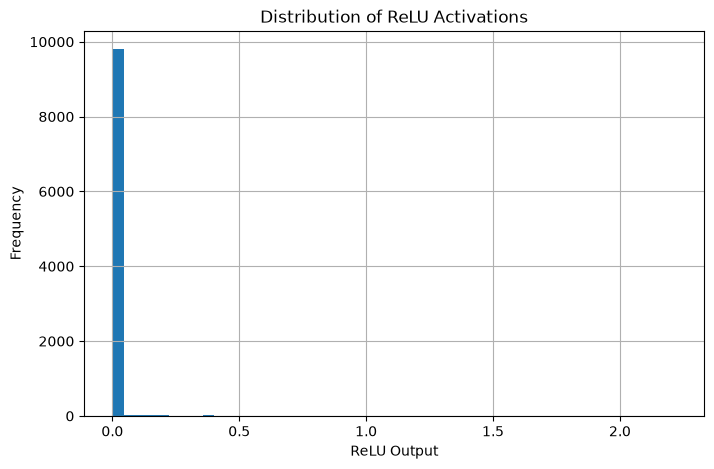

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(
    output.detach().numpy(),
    bins=50
)

plt.xlabel("ReLU Output")
plt.ylabel("Frequency")
plt.title("Distribution of ReLU Activations")
plt.grid(True)

plt.show()

A high proportion of zero activations means many neurons are inactive for these inputs.

This does not automatically mean that the entire network has dead neurons, but persistent zero activation can be a warning sign.

Possible alternatives include:

- Leaky ReLU
- ELU
- GELU

The choice of activation function should depend on the architecture and task.

# 18. Practical Experiment: Overfitting

We will create a small dataset and train a relatively large neural network.

Because the model has substantial capacity compared with the amount of training data, it can memorize training examples.

We will observe:

$$
\text{Training Loss} \downarrow
$$

while eventually:

$$
\text{Validation Loss} \uparrow
$$

This is a typical signature of overfitting.

In [19]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(
    n_samples=300,
    noise=0.25,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [20]:
model = nn.Sequential(
    nn.Linear(2, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 2)
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

train_losses = []
test_losses = []

for epoch in range(500):

    model.train()

    train_output = model(X_train)
    train_loss = criterion(train_output, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()

    with torch.no_grad():
        test_output = model(X_test)
        test_loss = criterion(test_output, y_test)

    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())

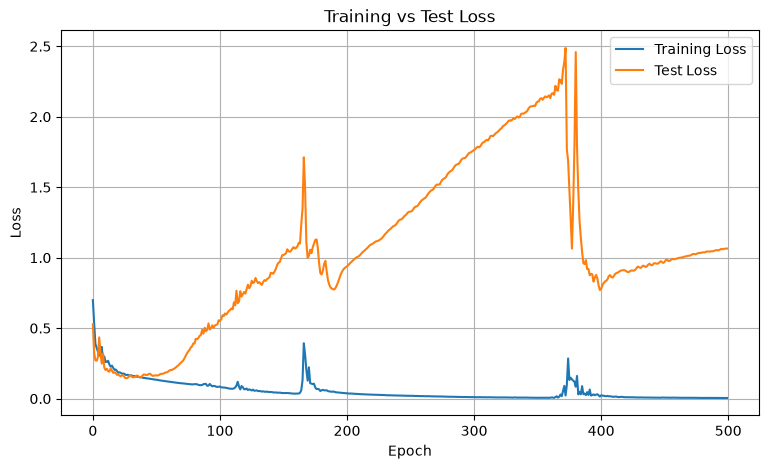

In [21]:
plt.figure(figsize=(9, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")
plt.legend()
plt.grid(True)

plt.show()

In [22]:
model.eval()

with torch.no_grad():
    train_predictions = model(X_train).argmax(dim=1)
    test_predictions = model(X_test).argmax(dim=1)

train_accuracy = accuracy_score(
    y_train.numpy(),
    train_predictions.numpy()
)

test_accuracy = accuracy_score(
    y_test.numpy(),
    test_predictions.numpy()
)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 1.0000
Test Accuracy: 0.9250


### Observation

If the training accuracy becomes substantially higher than the test accuracy, the model is showing signs of overfitting.

Common techniques for reducing overfitting include:

- More training data
- Data augmentation
- Dropout
- Weight decay
- Early stopping
- Regularization
- Smaller models
- Transfer learning

# 19. Practical Experiment: Class Imbalance

Consider a binary classification problem where:

$$
95\%
$$

of samples belong to Class 0 and only:

$$
5\%
$$

belong to Class 1.

A model that always predicts Class 0 can achieve:

$$
Accuracy = 95\%
$$

but it completely fails to recognize the minority class.

Therefore, accuracy alone can be misleading for imbalanced datasets.

Useful evaluation measures include:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion matrix

In [23]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

y_true = np.array(
    [0] * 95 + [1] * 5
)

y_pred = np.zeros(100, dtype=int)

print("Accuracy:", accuracy_score(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        zero_division=0
    )
)

Accuracy: 0.95

Confusion Matrix:
[[95  0]
 [ 5  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        95
           1       0.00      0.00      0.00         5

    accuracy                           0.95       100
   macro avg       0.47      0.50      0.49       100
weighted avg       0.90      0.95      0.93       100



### Observation

The classifier achieves high accuracy despite completely ignoring the minority class.

This demonstrates why evaluation metrics must be selected according to the problem rather than relying on accuracy alone.

# 20. Practical Experiment: Distribution Shift

A deep learning model generally assumes that training and deployment data are sufficiently similar.

However, real-world data can change.

For example:

- Training images may be captured in daylight.
- Deployment images may be captured at night.

Or:

- Training data may come from one camera.
- Deployment data may come from another camera.

Conceptually:

$$
P_{train}(X,Y)
\neq
P_{deployment}(X,Y)
$$

This phenomenon is called **distribution shift**.

We can visualize a simple example using two different input distributions.

In [24]:
np.random.seed(42)

train_data = np.random.normal(
    loc=0,
    scale=1,
    size=1000
)

deployment_data = np.random.normal(
    loc=2,
    scale=1,
    size=1000
)

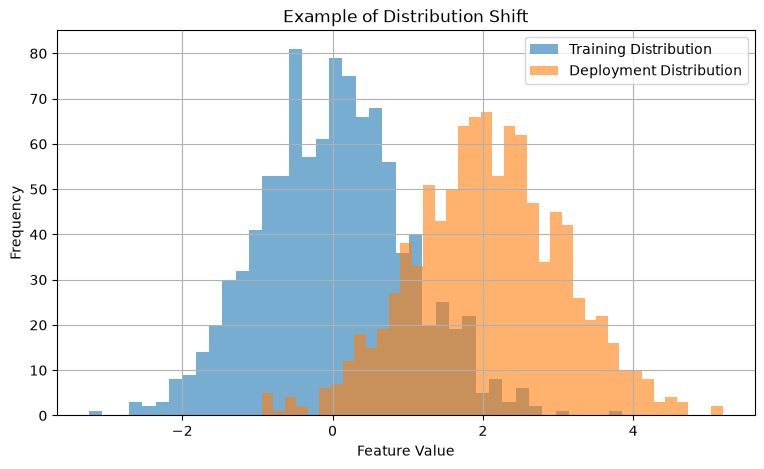

In [25]:
plt.figure(figsize=(9, 5))

plt.hist(
    train_data,
    bins=40,
    alpha=0.6,
    label="Training Distribution"
)

plt.hist(
    deployment_data,
    bins=40,
    alpha=0.6,
    label="Deployment Distribution"
)

plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.title("Example of Distribution Shift")
plt.legend()
plt.grid(True)

plt.show()

### Observation

The two distributions have different means.

Therefore, a model trained only on the first distribution may not perform equally well on the second distribution.

This is an important practical challenge in deploying deep learning systems.

Possible approaches include:

- Collecting more representative data
- Data augmentation
- Domain adaptation
- Domain generalization
- Continuous monitoring
- Retraining### Observation

The two distributions have different means.

Therefore, a model trained only on the first distribution may not perform equally well on the second distribution.

This is an important practical challenge in deploying deep learning systems.

Possible approaches include:

- Collecting more representative data
- Data augmentation
- Domain adaptation
- Domain generalization
- Continuous monitoring
- Retraining

# 21. Conceptual Relationship Between Major Issues

A Deep Learning system can be viewed as:

$$
\boxed{
\text{Data}
\rightarrow
\text{Representation}
\rightarrow
\text{Optimization}
\rightarrow
\text{Generalization}
\rightarrow
\text{Deployment}
}
$$

Each stage introduces potential problems.

### Data

- Insufficient data
- Noisy labels
- Class imbalance
- Data leakage
- Distribution shift

### Representation

- Poor features
- Dead neurons
- Inappropriate architecture

### Optimization

- Vanishing gradients
- Exploding gradients
- Poor initialization
- Learning-rate problems

### Generalization

- Overfitting
- Underfitting
- Dataset bias

### Deployment

- Computational cost
- Memory requirements
- Latency
- Distribution shift
- Interpretability

# 22. Final Summary

This notebook examined Deep Learning from multiple perspectives and studied important practical issues.

## Key Takeaways

### 1. Representation

Deep networks learn hierarchical representations through multiple layers.

### 2. Optimization

Neural networks are trained by minimizing a loss function using optimization algorithms.

### 3. Vanishing Gradients

Repeated multiplication of small derivatives can cause gradients to become extremely small.

### 4. Exploding Gradients

Repeated multiplication of large derivatives can cause gradients to become extremely large.

### 5. Initialization

Proper initialization helps maintain stable activations and gradients.

### 6. Dead Neurons

ReLU neurons can become permanently or persistently inactive when they receive negative inputs.

### 7. Overfitting

A high-capacity network may memorize training data and perform poorly on unseen data.

### 8. Class Imbalance

High accuracy does not necessarily indicate good performance when classes are imbalanced.

### 9. Distribution Shift

Changes between training and deployment distributions can significantly reduce model performance.

### 10. Interpretability

Understanding the internal reasoning of complex neural networks remains challenging.

### 11. Computation

Deep learning can require substantial computational resources and memory.

---

## Final Perspective

Successful Deep Learning requires more than selecting a neural-network architecture.

A complete system must consider:

$$
\boxed{
\text{Data}
+
\text{Architecture}
+
\text{Initialization}
+
\text{Optimization}
+
\text{Regularization}
+
\text{Evaluation}
+
\text{Deployment}
}
$$

Understanding these perspectives and issues is essential for both theoretical understanding and practical Deep Learning.